# CSE5280 — Evacuation Simulation: Three-Floor Building


---

### Design: Every agent navigates their current floor's layout


Floor 2 agent  →  navigate Floor 2 corridors/walls  →  reach Ramp 2 entry  → descend Ramp 2  (z: 6 → 3)
Floor 1 agent  →  navigate Floor 1 corridors/walls  →  reach Ramp 1 entry  → descend Ramp 1  (z: 3 → 0)
Floor 0 agent  →  navigate Ground corridors/walls   →  Exit A or Exit B (soft-min)


**All motion emerges from gradient descent on a scalar cost function.**
No path planning, no teleportation, no hard floor-switching.



In [1]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os, sys, subprocess

import vedo

H = 3.0     # floor-to-floor height
W = 0.2     # wall thickness


## Building Constants

Three floors at $z = 0,\ H,\ 2H$ with $H=3$.

**Exits** (ground floor only):
- Exit A — west wall gap $x=0,\ y\in[6,9]$
- Exit B — north wall gap $y=14,\ x\in[16,19]$

**Ramps:**
- Ramp 1: Ground → Floor 1, centerline $(19,7)\to(23,7)$, $z:0\to H$
- Ramp 2: Floor 1 → Floor 2, centerline $(23,10)\to(19,10)$, $z:H\to 2H$

**Ramp waypoints** — the target agents aim for on each upper floor (mid-entry point):
- Floor 2 agents aim for $(21,\ 10,\ 2H)$ — Ramp 2 mid-entry
- Floor 1 agents aim for $(21,\ 7,\ H)$ — Ramp 1 mid-entry


In [2]:
# ── Exits ─────────────────────────────────────────────────────────────────────
EXIT_A = np.array([0.0,  7.5, 0.0])
EXIT_B = np.array([17.5, 14.0, 0.0])
EXITS  = [EXIT_A, EXIT_B]

# ── Ramps ─────────────────────────────────────────────────────────────────────
RAMP1 = dict(A=np.array([19., 7.]), B=np.array([23., 7.]), z0=0.,  z1=H,   r=1.0)
RAMP2 = dict(A=np.array([23.,10.]), B=np.array([19.,10.]), z0=H,   z1=2*H, r=1.0)
RAMPS = [RAMP1, RAMP2]

# ── Ramp waypoints per floor (xy target agents walk toward) ───────────────────
# Using mid-ramp x so agents enter the capsule before the cost switches
RAMP_WP = {
    2: np.array([21., 10., 2*H]),   # Floor 2 → aim for Ramp 2 mid
    1: np.array([21.,  7.,  H  ]),  # Floor 1 → aim for Ramp 1 mid
}

# ── Wall segments (from your floor files) ────────────────────────────────────
# Ground floor (floor1.py wall_segments)
WALLS_F0 = [
    ((0,0),(10,0)),((10,0),(15,0)),((15,0),(20,0)),((20,0),(25,0)),
    ((0,0),(0,5)),((0,5),(0,6)),((0,9),(0,10)),((0,10),(0,14)),
    ((0,14),(10,14)),((10,14),(15,14)),((15,14),(16,14)),
    ((19,14),(20,14)),((20,14),(25,14)),
    ((25,0),(25,3)),((25,3),(25,11)),((25,11),(25,14)),
    ((10,0),(10,5)),((10,10),(10,14)),
    ((15,0),(15,2)),((15,2),(15,5)),((15,10),(15,14)),
    ((20,0),(20,2)),((20,2),(20,3)),((20,12),(20,14)),
    ((0,5),(6,5)),((9,5),(10,5)),((12,5),(15,5)),
    ((0,10),(6,10)),((9,10),(13,10)),
    ((15,2),(16,2)),((18,2),(20,2)),
    ((22,3),(25,3)),((20,11),(25,11)),
]
# Upper floors (floor2.py / floor3.py wall_segments — identical footprint)
WALLS_UPPER = [
    ((0,0),(10,0)),((10,0),(15,0)),((15,0),(25,0)),
    ((0,0),(0,7)),((0,7),(0,14)),
    ((0,14),(10,14)),((10,14),(15,14)),((15,14),(20,14)),((20,14),(25,14)),
    ((25,0),(25,4)),((25,4),(25,14)),
    ((18,4),(20,4)),((20,4),(25,4)),
    ((15,0),(15,4)),
    ((10,0),(10,2)),((10,4),(10,7)),((10,7),(10,11)),((10,13),(10,14)),
    ((0,7),(10,7)),
]
WALLS = {0: WALLS_F0, 1: WALLS_UPPER, 2: WALLS_UPPER}



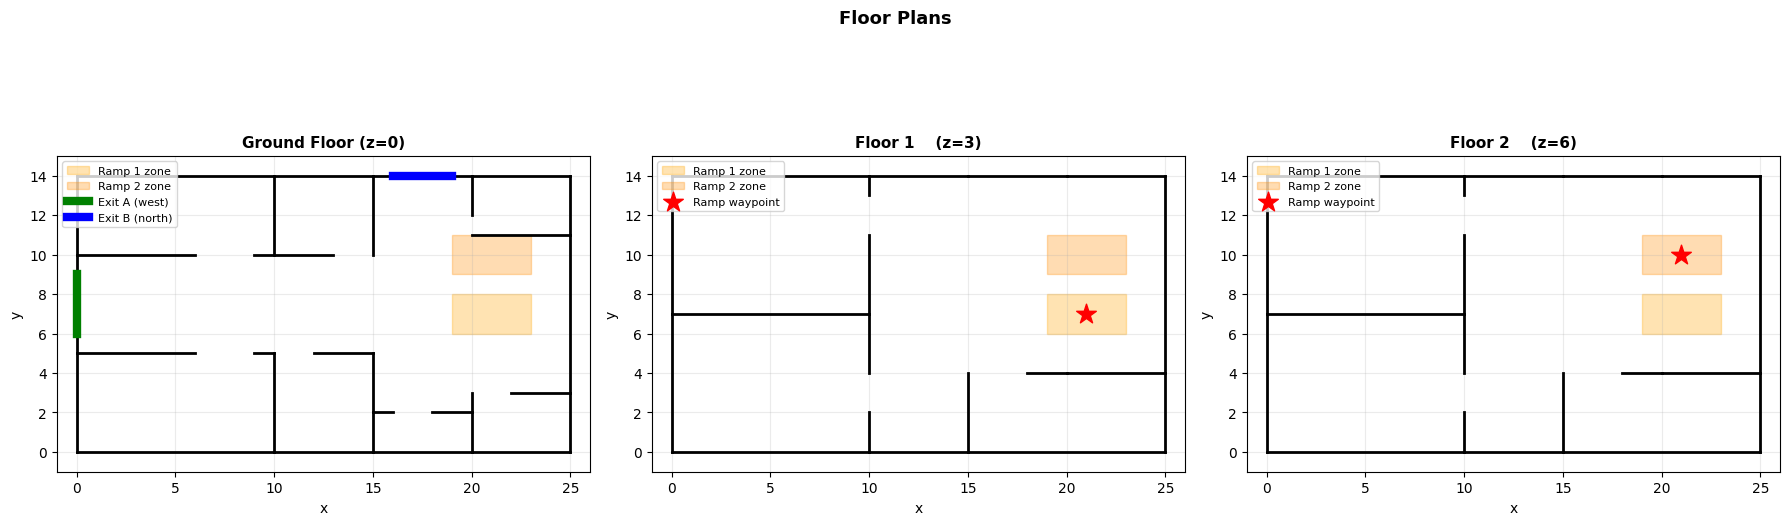

In [3]:
# ── Visualise floor plans with wall segments, exits, ramp zones ───────────────
fig, axs = plt.subplots(1, 3, figsize=(18,6))
floor_titles = ['Ground Floor (z=0)',
                'Floor 1    (z=3)',
                'Floor 2    (z=6)']

for fi, (ax, title) in enumerate(zip(axs, floor_titles)):
    # Walls
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2],'k-',lw=2)
    # Ramp zones
    ax.add_patch(plt.Rectangle((19,6),4,2, color='orange',     alpha=0.30, label='Ramp 1 zone'))
    ax.add_patch(plt.Rectangle((19,9),4,2, color='darkorange', alpha=0.30, label='Ramp 2 zone'))
    # Exits on ground floor only
    if fi == 0:
        ax.plot([0,0],[6,9],  'g-', lw=6, label='Exit A (west)')
        ax.plot([16,19],[14,14],'b-',lw=6, label='Exit B (north)')
    # Ramp waypoint
    if fi in RAMP_WP:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0],wp[1], c='red', s=220, marker='*', zorder=6, label='Ramp waypoint')
    ax.set_xlim(-1,26); ax.set_ylim(-1,15); ax.set_aspect('equal')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.25)

plt.suptitle('Floor Plans',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Ramp Modeling 

A ramp is a piecewise-planar surface patch embedded in $\mathbb{R}^3$.


$$u(x,y) = \text{clip}\!\left(\frac{(P-A)\cdot v}{\|v\|^2},\ 0,\ 1\right), \quad v = B - A$$


$$z_{\text{ramp}}(x,y) = z_0 + (z_1 - z_0)\,u(x,y)$$


$$\mathcal{R} = \{(x,y)\mid \text{dist}((x,y),\,[A,B]) \le r\}$$


$$z_{\text{surf}}(x,y) = (1-g)\,z_{\text{floor}} + g\,z_{\text{ramp}}(x,y), \quad
g = \mathbf{1}_{(x,y)\in\mathcal{R}}$$

Outside the capsule the surface is flat; inside it follows the incline.


In [4]:
# ── Ramp geometry ─────────────────────────────────────────────────────────────

def dist_seg(xy, A, B):
    """2-D distance from point xy to segment A–B."""
    v = B - A;  w = xy - A
    t = np.clip(np.dot(w,v)/np.dot(v,v), 0., 1.)
    return float(np.linalg.norm(xy - (A + t*v)))

def ramp_u(xy, ramp):
    v = ramp['B'] - ramp['A']
    return float(np.clip(np.dot(xy-ramp['A'], v)/np.dot(v,v), 0., 1.))

def ramp_height(xy, ramp):
    return ramp['z0'] + (ramp['z1']-ramp['z0']) * ramp_u(xy, ramp)

def in_ramp(xy, ramp):
    return dist_seg(xy, ramp['A'], ramp['B']) <= ramp['r']

def z_surf(xy, floor_z):
    """Blended surface height — flat floor outside ramp capsule, incline inside."""
    for ramp in RAMPS:
        if in_ramp(xy, ramp):
            return ramp_height(xy, ramp)
    return float(floor_z)

def get_floor_z(z):
    """Snap DOWN to highest floor base ≤ z (prevents pulling agent to wrong floor)."""
    floors = [0., H, 2*H]
    below  = [fz for fz in floors if fz <= z + 0.01]
    return float(below[-1]) if below else 0.

def detect_floor(z):
    """Return floor index 0/1/2 from z coordinate."""
    if   z < H*0.6:  return 0
    elif z < H*1.6:  return 1
    else:            return 2




##  Cost Function

$$C = C_{\text{goal}} + C_{\text{walls}} + C_{\text{height}} + C_{\text{smooth}} + C_{\text{repulsion}}$$

---

### Floor-Aware Goal Attraction

The target changes every step based on `detect_floor(z)`:

$$C_{\text{goal}}(p,\ f) = \begin{cases}
-\tau\log\!\displaystyle\sum_{i=1}^{2}\exp\!\left(-\dfrac{\|p-p_i^{\text{exit}}\|^2}{\tau}\right) & f=0
\quad\text{(soft-min, required)}\\[8pt]
w_{\text{wp}}\,\bigl((p_x - wp_x)^2 + (p_y - wp_y)^2\bigr) & f=1\text{ or }2
\end{cases}$$

- **Floor 0** — soft-min pulls agent to whichever exit is closer; $\tau=1.0$ gives a smooth split
- **Floor 1** — squared-distance pull in $(x,y)$ toward Ramp 1 mid-entry $(21,7)$
- **Floor 2** — squared-distance pull in $(x,y)$ toward Ramp 2 mid-entry $(21,10)$

Because `C_walls` uses each floor's real wall layout, agents must **navigate corridors and door
gaps** to reach the waypoint — they cannot pass through walls.

---

###  Wall Penalty — Quadratic Band

$$C_{\text{walls}}(p,\ f) = \sum_k w_{\text{wall}}\,(\text{band}-d_k)^2\,\mathbf{1}_{d_k<\text{band}}$$

$d_k$ = distance from agent $(x,y)$ to wall segment $k$ on floor $f$.  
Parameters: $\text{band}=0.6$, $w_{\text{wall}}=12$.

---

###  Surface Adherence

$$C_{\text{height}} = w_h\,(z - z_{\text{surf}}(x,y))^2, \quad w_h = 50$$

Once an agent enters a ramp capsule footprint, $z_{\text{surf}}$ becomes the inclined ramp
surface — the gradient of $C_{\text{height}}$ automatically rides the agent down.

---

###  Smoothness & Repulsion

$$C_{\text{smooth}} = w_s\,\|p^{k+1}-p^k\|^2 \qquad
C_{\text{rep}} = \sum_{j\ne i} w_{\text{rep}}(r_{\text{rep}}-\|p_i-p_j\|)^2_+$$


In [5]:
# ── Cost functions ────────────────────────────────────────────────────────────

def cost_goal(p, floor_idx, tau=1.0, w_wp=30.0):
    """
    Floor-aware goal:
      floor 0  → soft-min over Exit A, Exit B
      floor 1  → squared distance to Ramp-1 waypoint (xy only)
      floor 2  → squared distance to Ramp-2 waypoint (xy only)
    """
    p = np.asarray(p, dtype=float)
    if floor_idx == 0:
        # Soft-min (required by assignment)
        exps = []
        for e in EXITS:
            d2 = (p[0]-e[0])**2 + (p[1]-e[1])**2 + 0.05*(p[2]-e[2])**2
            exps.append(np.exp(-float(d2)/tau))
        return float(-tau * np.log(max(sum(exps), 1e-300)))
    else:
        wp   = RAMP_WP[floor_idx]
        # Pull only in xy — C_height handles z
        return float(w_wp * ((p[0]-wp[0])**2 + (p[1]-wp[1])**2))

def cost_walls(p, floor_idx, band=0.6, w_wall=12.0):
    """Quadratic band penalty — uses the correct floor's wall list."""
    xy    = np.asarray(p, dtype=float)[:2]
    total = 0.
    for (x1,y1),(x2,y2) in WALLS[floor_idx]:
        d = dist_seg(xy, np.array([x1,y1],float), np.array([x2,y2],float))
        if d < band:
            total += w_wall * 0.5*(band - d)**2
        else:
            total+=w_wall
    return total

def cost_height(p, w_h=50.0):
    """Keep agent glued to floor surface or ramp incline."""
    p  = np.asarray(p, dtype=float)
    fz = get_floor_z(p[2])
    return float(w_h * (p[2] - z_surf(p[:2], fz))**2)

def cost_smooth(p_new, p_old, w_s=0.2):
    d = np.asarray(p_new,float) - np.asarray(p_old,float)
    return float(w_s * np.dot(d,d))

def cost_repulsion(i, positions, r_rep=0.9, w_rep=6.0):
    total = 0.
    pi = positions[i]
    for j, pj in enumerate(positions):
        if j == i: continue
        d = float(np.linalg.norm(pi - pj))
        if 1e-6 < d < r_rep:
            total += w_rep * (r_rep - d)**2
    return total

def total_cost(i, positions, p_old, floor_idx,
               tau=1.0, w_wp=30.0, band=0.6, w_wall=12.0,
               w_h=50.0, w_s=0.2, r_rep=0.9, w_rep=6.0):
    p  = positions[i]
    C  = cost_goal(p, floor_idx, tau=tau, w_wp=w_wp)
    C += cost_walls(p, floor_idx, band=band, w_wall=w_wall)
    C += cost_height(p, w_h=w_h)
    C += cost_smooth(p, p_old, w_s=w_s)
    C += cost_repulsion(i, positions, r_rep=r_rep, w_rep=w_rep)
    return float(C)

def fd_gradient(i, positions, p_old, floor_idx, eps=1e-4, **kw):
    """Central-difference gradient of total_cost w.r.t. positions[i]. Returns (3,)."""
    grad = np.zeros(3)
    pos  = [np.array(q, dtype=float) for q in positions]
    for k in range(3):
        pos[i][k] += eps
        Cp = total_cost(i, pos, p_old, floor_idx, **kw)
        pos[i][k] -= 2*eps
        Cm = total_cost(i, pos, p_old, floor_idx, **kw)
        pos[i][k] += eps          # restore
        grad[k] = (Cp - Cm) / (2*eps)
    return grad





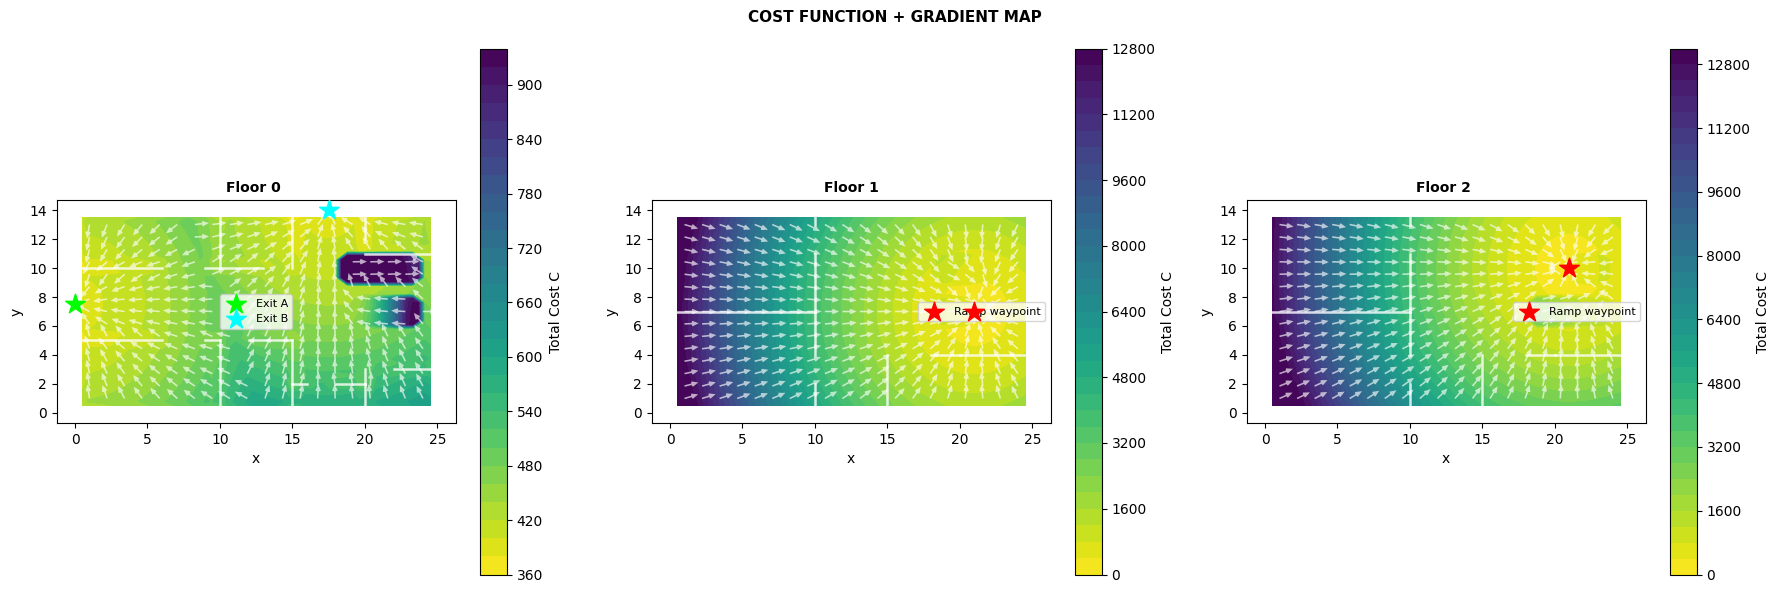

In [6]:
#  Visualise TOTAL COST FUNCTION per floor + gradient arrows 

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
floor_zs   = [0., H, 2*H]
subtitles  = [
    'Floor 0 ',
    'Floor 1',
    'Floor 2 ',
]

# Coarse grid for cost heatmap
xs_c = np.linspace(0.5, 24.5, 60)
ys_c = np.linspace(0.5, 13.5, 45)
XX_c, YY_c = np.meshgrid(xs_c, ys_c)

# Fine grid for gradient arrows (quiver)
xs_q = np.linspace(1, 24, 20)
ys_q = np.linspace(1, 13, 15)
XX_q, YY_q = np.meshgrid(xs_q, ys_q)

for fi, (ax, fz, sub) in enumerate(zip(axs, floor_zs, subtitles)):

    # ── Cost heatmap ─────────────────────────────────────────────────────────
    ZZ = np.zeros_like(XX_c)
    # Use a single dummy agent; neighbours far away so C_rep ≈ 0
    dummy_positions = [np.array([100., 100., fz])] * 5   # 5 far-away dummies
    for i in range(XX_c.shape[0]):
        for j in range(XX_c.shape[1]):
            p = np.array([XX_c[i,j], YY_c[i,j], fz])
            dummy_positions[0] = p
            ZZ[i,j] = total_cost(0, dummy_positions, p, fi)

    # Clip extreme values for better colour contrast
    vmax = np.percentile(ZZ, 97)
    cp   = ax.contourf(XX_c, YY_c, np.clip(ZZ, 0, vmax),
                       levels=35, cmap='viridis_r')
    plt.colorbar(cp, ax=ax, label='Total Cost C')

    # ── Gradient arrow field ─────────────────────────────────────────────────
    UU = np.zeros_like(XX_q)
    VV = np.zeros_like(YY_q)
    dummy_positions = [np.array([100., 100., fz])] * 5
    for i in range(XX_q.shape[0]):
        for j in range(XX_q.shape[1]):
            p = np.array([XX_q[i,j], YY_q[i,j], fz])
            dummy_positions[0] = p
            g = fd_gradient(0, dummy_positions, p, fi)
            # Descent direction = -gradient (normalised for visibility)
            gxy = np.array([g[0], g[1]])
            nm  = np.linalg.norm(gxy)
            if nm > 1e-6:
                gxy = gxy / nm
            UU[i,j] = -gxy[0]   # descent direction
            VV[i,j] = -gxy[1]

    ax.quiver(XX_q, YY_q, UU, VV,
              color='white', alpha=0.65, scale=28, width=0.004,
              headwidth=3.5, headlength=4)

    # ── Walls ────────────────────────────────────────────────────────────────
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2], 'w-', lw=1.8, alpha=0.8)

    # ── Targets ──────────────────────────────────────────────────────────────
    if fi == 0:
        ax.scatter(*EXIT_A[:2], c='lime', s=220, marker='*',
                   zorder=6, label='Exit A')
        ax.scatter(*EXIT_B[:2], c='cyan', s=220, marker='*',
                   zorder=6, label='Exit B')
    else:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0], wp[1], c='red', s=220, marker='*',
                   zorder=6, label='Ramp waypoint')

    ax.set_title(sub, fontweight='bold', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal'); ax.legend(fontsize=8)

plt.suptitle(
    'COST FUNCTION + GRADIENT MAP',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(); plt.show()


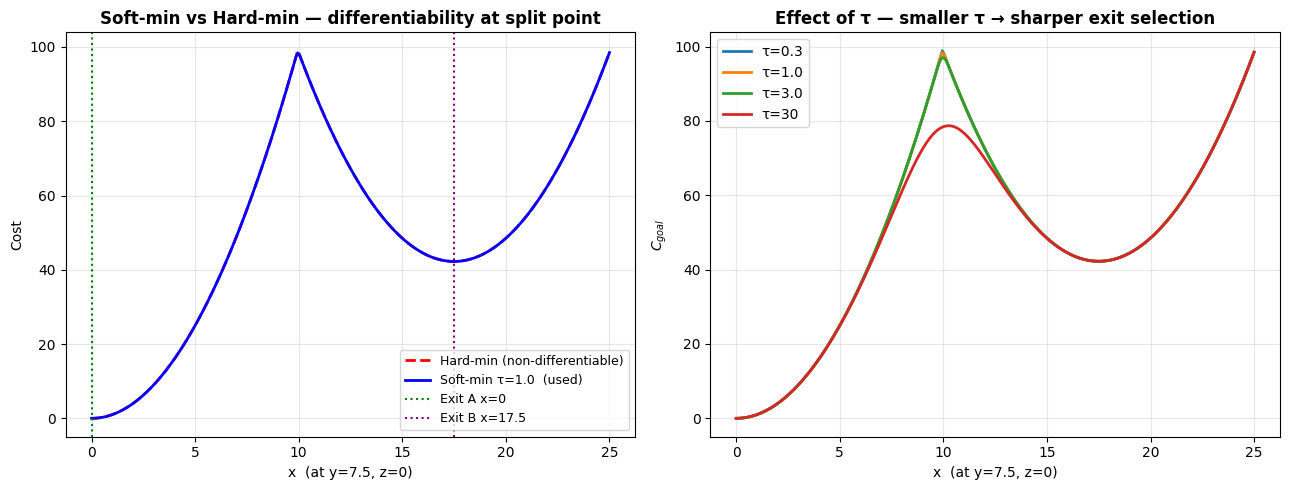

In [7]:
# ── Soft-min analysis (Floor 0) ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

xs_line = np.linspace(0, 25, 300)
p_line  = [np.array([x, 7.5, 0.0]) for x in xs_line]

hard = [min(np.dot(p-EXIT_A, p-EXIT_A), np.dot(p-EXIT_B, p-EXIT_B)) for p in p_line]
soft = [cost_goal(p, floor_idx=0, tau=1.0) for p in p_line]

ax1.plot(xs_line, hard, 'r--', lw=2, label='Hard-min (non-differentiable)')
ax1.plot(xs_line, soft, 'b-',  lw=2, label='Soft-min τ=1.0  (used)')
ax1.axvline(EXIT_A[0], color='green',  ls=':', label='Exit A x=0')
ax1.axvline(EXIT_B[0], color='purple', ls=':', label='Exit B x=17.5')
ax1.set_xlabel('x  (at y=7.5, z=0)'); ax1.set_ylabel('Cost')
ax1.set_title('Soft-min vs Hard-min — differentiability at split point', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

for tau in [0.3, 1.0, 3.0,30]:
    ax2.plot(xs_line, [cost_goal(p, 0, tau=tau) for p in p_line], lw=2, label=f'τ={tau}')
ax2.set_xlabel('x  (at y=7.5, z=0)'); ax2.set_ylabel('$C_{goal}$')
ax2.set_title('Effect of τ — smaller τ → sharper exit selection', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Agent Initialisation 

**20 agents RANDOMLY DISTRIBUTED**

Colour legend used throughout:
- Blue — started Floor 0
- Orange — started Floor 1
- Red — started Floor 2


Agents per floor: [6, 6, 8]


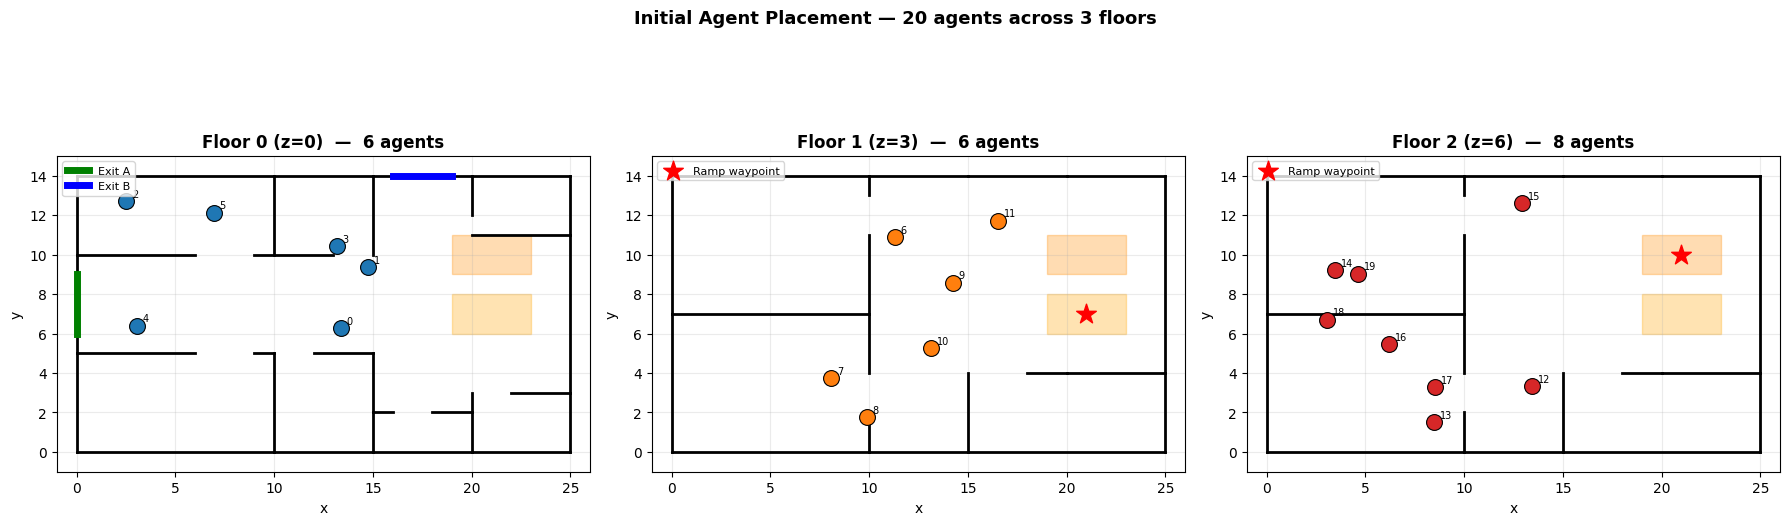

In [8]:
def init_agents(n=20, seed=2026):
    rng    = np.random.default_rng(seed)
    positions, floors = [], []
    counts = [n//3, n//3, n - 2*(n//3)]   # [6, 6, 8]
    for fi, cnt in enumerate(counts):
        fz = fi * H
        for _ in range(cnt):
            while True:
                x  = rng.uniform(1., 17.)
                y  = rng.uniform(1., 13.)
                xy = np.array([x, y])
                if not any(in_ramp(xy, r) for r in RAMPS):
                    break
            positions.append(np.array([x, y, fz]))
            floors.append(fi)
    return np.array(positions, dtype=float), floors

positions_init, start_floors = init_agents(20, 42)
FLOOR_COLORS = ['#1f77b4', '#ff7f0e', '#d62728']   # blue, orange, red
AGENT_COLORS = [FLOOR_COLORS[f] for f in start_floors]

print(f"Agents per floor: {[start_floors.count(f) for f in range(3)]}")

# ── Plot initial positions on each floor ─────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for fi, ax in enumerate(axs):
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2],'k-',lw=2)
    ax.add_patch(plt.Rectangle((19,6),4,2, color='orange',     alpha=0.30))
    ax.add_patch(plt.Rectangle((19,9),4,2, color='darkorange', alpha=0.30))
    if fi == 0:
        ax.plot([0,0],[6,9],   'g-', lw=5, label='Exit A')
        ax.plot([16,19],[14,14],'b-', lw=5, label='Exit B')
    if fi in RAMP_WP:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0], wp[1], c='red', s=220, marker='*', zorder=6, label='Ramp waypoint')
    idxs = [i for i,f in enumerate(start_floors) if f==fi]
    pts  = positions_init[idxs]
    ax.scatter(pts[:,0], pts[:,1], c=FLOOR_COLORS[fi], s=130,
               edgecolors='black', lw=0.8, zorder=5)
    for idx, p in zip(idxs, pts):
        ax.annotate(str(idx), (p[0]+0.3, p[1]+0.2), fontsize=7)
    ax.set_xlim(-1,26); ax.set_ylim(-1,15); ax.set_aspect('equal')
    ax.set_title(f'Floor {fi} (z={fi*H:.0f})  —  {len(idxs)} agents', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.25)
plt.suptitle('Initial Agent Placement — 20 agents across 3 floors', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Simulation Loop

- Upper-floor agents **navigate their floor's corridors** to the ramp
- Descent happens via $C_{\text{height}}$ riding the ramp incline
- Ground-floor agents **navigate ground corridors** to Exit A or Exit B


In [9]:
SIM_PARAMS = dict(
    n_agents  = 20,
    n_steps   = 1500,
    lr        = 0.06,       # learning rate
    max_step  = 0.25,       # per-component step cap
    momentum  = 0.35,       # velocity decay
    exit_tol  = 1.5,        # exit capture radius
    eps       = 1e-4,       # finite-difference epsilon
    noise     = 0.02,       # horizontal noise for saddle escape
    seed      = 2026,
    # cost weights
    tau    = 1.0,
    w_wp   = 30.0,
    band   = 0.6,
    w_wall = 12.0,
    w_h    = 50.0,
    w_s    = 0.2,
    r_rep  = 0.9,
    w_rep  = 6.0,
)

def run_simulation(params=None, record_every=1, verbose=True):
    p          = params or SIM_PARAMS
    positions, _ = init_agents(n=p['n_agents'], seed=p['seed'])
    N          = len(positions)
    velocities = np.zeros((N, 3))
    escaped    = [False]*N
    escape_step= [-1]*N
    history    = []
    rng        = np.random.default_rng(p['seed']+99)

    cost_kw = {k: p[k] for k in
               ['tau','w_wp','band','w_wall','w_h','w_s','r_rep','w_rep']}

    last_step = p['n_steps'] - 1
    for step in range(p['n_steps']):
        if step % record_every == 0:
            history.append(positions.copy())

        active = [i for i in range(N) if not escaped[i]]
        if not active:
            last_step = step
            if verbose: print(f"All agents escaped at step {step}!")
            break

        new_pos = positions.copy()
        for i in active:
            p_old  = positions[i].copy()
            fi     = detect_floor(positions[i][2])  # recomputed every step

            grad   = fd_gradient(i, positions, p_old, fi, eps=p['eps'], **cost_kw)

            noise       = p['noise'] * rng.standard_normal(3)
            noise[2]    = 0.                          # no vertical noise
            velocities[i] = (p['momentum']*velocities[i]
                             - p['lr']*grad + noise)
            velocities[i] = np.clip(velocities[i], -p['max_step'], p['max_step'])

            p_new    = positions[i] + velocities[i]
            p_new[0] = np.clip(p_new[0], 0., 25.)
            p_new[1] = np.clip(p_new[1], 0., 14.)
            p_new[2] = np.clip(p_new[2], 0., 2*H+0.15)
            new_pos[i] = p_new

            # Exit detection — only relevant once agent reaches ground floor
            if fi == 0:
                for exit_pt in EXITS:
                    if np.linalg.norm(p_new - exit_pt) < p['exit_tol']:
                        escaped[i]      = True
                        escape_step[i]  = step
                        new_pos[i]      = exit_pt.copy()
                        velocities[i]   = np.zeros(3)
                        break

        positions = new_pos

    history.append(positions.copy())

    if verbose:
        n_esc = sum(escaped)
        print(f"\n{'='*48}")
        print(f"  Simulation complete")
        print(f"{'='*48}")
        print(f"  Steps run      : {last_step+1}")
        print(f"  Agents escaped : {n_esc} / {N}")
        print(f"  Stuck          : {N - n_esc}")
        print(f"{'─'*48}")
        for i in range(N):
            fi = detect_floor(positions[i][2])
            if escaped[i]:
                print(f"  Agent {i:2d}: ESCAPED  step {escape_step[i]:4d}")
            else:
                print(f"  Agent {i:2d}: STUCK    floor={fi}  pos={positions[i].round(2)}")
        print(f"{'='*48}")

    return history, escaped, escape_step, positions




In [10]:

print("Running simulation ")
history, escaped, escape_step, final_pos = run_simulation(
    SIM_PARAMS, record_every=1, verbose=True)

history_arr = np.array(history)   # shape (frames, N, 3)
N = history_arr.shape[1]
print(f"\nTrajectory shape: {history_arr.shape}  (frames × agents × xyz)")


Running simulation 

  Simulation complete
  Steps run      : 1500
  Agents escaped : 13 / 20
  Stuck          : 7
────────────────────────────────────────────────
  Agent  0: ESCAPED  step    9
  Agent  1: ESCAPED  step   27
  Agent  2: ESCAPED  step   20
  Agent  3: ESCAPED  step   37
  Agent  4: ESCAPED  step   31
  Agent  5: ESCAPED  step    2
  Agent  6: STUCK    floor=0  pos=[21.39  7.21  1.54]
  Agent  7: ESCAPED  step  133
  Agent  8: STUCK    floor=0  pos=[19.72  9.32  0.73]
  Agent  9: ESCAPED  step  633
  Agent 10: ESCAPED  step  695
  Agent 11: STUCK    floor=0  pos=[21.15 10.66  1.6 ]
  Agent 12: ESCAPED  step  558
  Agent 13: STUCK    floor=2  pos=[20.63 10.14  5.18]
  Agent 14: STUCK    floor=2  pos=[20.97  9.59  4.8 ]
  Agent 15: ESCAPED  step  162
  Agent 16: ESCAPED  step  213
  Agent 17: STUCK    floor=0  pos=[20.77 10.09  1.07]
  Agent 18: ESCAPED  step  834
  Agent 19: STUCK    floor=0  pos=[21.38  7.48  1.62]

Trajectory shape: (1501, 20, 3)  (frames × agents × xy

## Results

In [11]:
positions_init, start_floors = init_agents(20, SIM_PARAMS['seed'])
FLOOR_COLORS = ['#1f77b4','#ff7f0e','#d62728']
AGENT_COLORS = [FLOOR_COLORS[f] for f in start_floors]

n_esc  = sum(escaped)
exit_A = sum(1 for i in range(N) if escaped[i]
             and np.linalg.norm(final_pos[i]-EXIT_A)<1.5)
exit_B = n_esc - exit_A

print(f"Total agents   : {N}")
print(f"Escaped        : {n_esc} / {N}  ({100*n_esc/N:.0f}%)")
print(f"  via Exit A   : {exit_A}")
print(f"  via Exit B   : {exit_B}")
for fi in range(3):
    ag = [i for i,f in enumerate(start_floors) if f==fi]
    ne = sum(escaped[i] for i in ag)
    print(f"  Floor {fi} ({len(ag)} agents): {ne} escaped")


Total agents   : 20
Escaped        : 13 / 20  (65%)
  via Exit A   : 3
  via Exit B   : 10
  Floor 0 (6 agents): 6 escaped
  Floor 1 (6 agents): 3 escaped
  Floor 2 (8 agents): 4 escaped


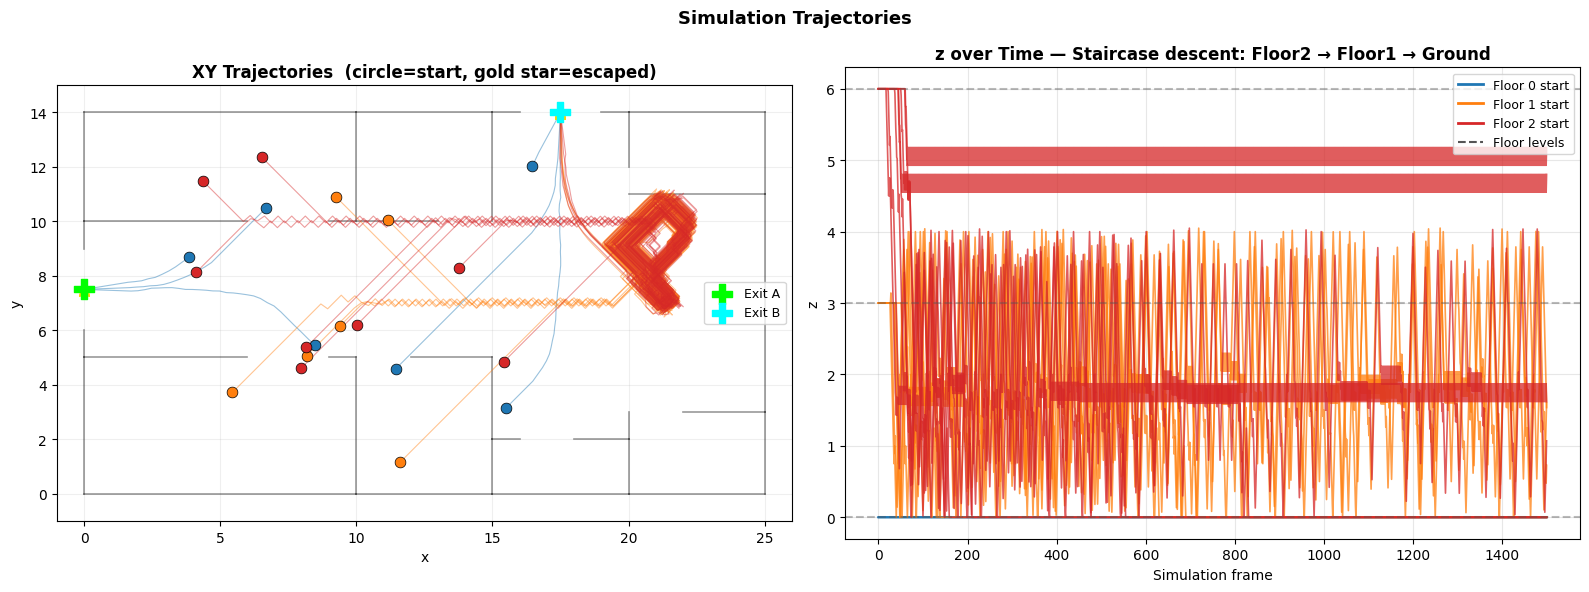

In [12]:
# ── Trajectory plots ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── XY trajectories (projected onto ground floor plan) ───────────────────────
for (x1,y1),(x2,y2) in WALLS_F0:
    ax1.plot([x1,x2],[y1,y2],'k-',lw=1.2,alpha=0.4)
for i in range(N):
    traj = history_arr[:,i,:]
    ax1.plot(traj[:,0], traj[:,1], '-', color=AGENT_COLORS[i], lw=0.8, alpha=0.45)
    ax1.scatter(traj[0,0], traj[0,1], c=AGENT_COLORS[i], s=60,
                edgecolors='k', lw=0.5, zorder=4)
    if escaped[i]:
        ax1.scatter(traj[-1,0], traj[-1,1], marker='*', c='gold', s=140, zorder=5)
ax1.scatter(*EXIT_A[:2], marker='P', c='lime', s=220, zorder=6, label='Exit A')
ax1.scatter(*EXIT_B[:2], marker='P', c='cyan', s=220, zorder=6, label='Exit B')
ax1.set_xlim(-1,26); ax1.set_ylim(-1,15); ax1.set_aspect('equal')
ax1.set_title('XY Trajectories  (circle=start, gold star=escaped)', fontweight='bold')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2)

# ── z over time — staircase descent through ramps ────────────────────────────
for i in range(N):
    ax2.plot(history_arr[:,i,2], '-', color=AGENT_COLORS[i], lw=1.2, alpha=0.75)
for z, lbl in [(0,'z=0  Ground'),(H,f'z={H}  Floor 1'),(2*H,f'z={2*H}  Floor 2')]:
    ax2.axhline(z, color='#555', ls='--', alpha=0.4, label=lbl)
ax2.set_xlabel('Simulation frame'); ax2.set_ylabel('z')
ax2.set_title('z over Time — Staircase descent: Floor2 → Floor1 → Ground',
              fontweight='bold')
handles = [Line2D([0],[0],color=c,lw=2,label=f'Floor {f} start')
           for f,c in enumerate(FLOOR_COLORS)]
handles += [Line2D([0],[0],color='#555',ls='--',label='Floor levels')]
ax2.legend(handles=handles, fontsize=9); ax2.grid(True, alpha=0.3)
plt.suptitle('Simulation Trajectories', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


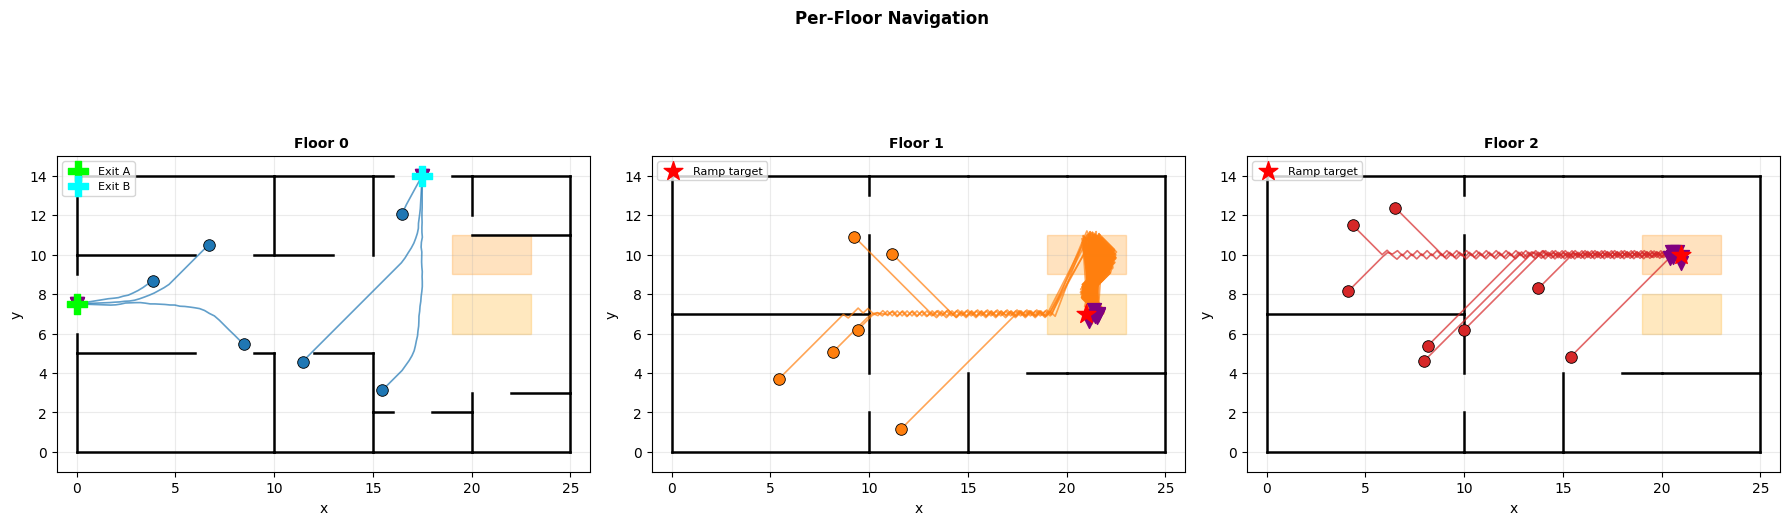

In [13]:
# ── Per-floor XY trajectories (agents navigate their own floor) ───────────────
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for fi, ax in enumerate(axs):
    for (x1,y1),(x2,y2) in WALLS[fi]:
        ax.plot([x1,x2],[y1,y2],'k-',lw=1.8)
    ax.add_patch(plt.Rectangle((19,6),4,2,color='orange',    alpha=0.25))
    ax.add_patch(plt.Rectangle((19,9),4,2,color='darkorange',alpha=0.25))

    # For agents that STARTED on this floor, show only the portion of
    # their trajectory while they were on this floor
    idxs = [i for i,f in enumerate(start_floors) if f==fi]
    for i in idxs:
        traj = history_arr[:,i,:]
        # Frames where detect_floor(z) == fi
        mask  = np.array([detect_floor(z)==fi for z in traj[:,2]])
        segs  = traj[mask]
        if len(segs) > 1:
            ax.plot(segs[:,0], segs[:,1], '-', color=FLOOR_COLORS[fi],
                    lw=1.2, alpha=0.7)
            ax.scatter(segs[0,0],  segs[0,1],  c=FLOOR_COLORS[fi],
                       s=70, edgecolors='k', lw=0.6, zorder=4)
            # Mark where agent leaves this floor (enters ramp)
            ax.scatter(segs[-1,0], segs[-1,1], marker='v', c='purple',
                       s=100, zorder=5)

    if fi == 0:
        ax.scatter(*EXIT_A[:2], marker='P', c='lime', s=200, zorder=6, label='Exit A')
        ax.scatter(*EXIT_B[:2], marker='P', c='cyan', s=200, zorder=6, label='Exit B')
    if fi in RAMP_WP:
        wp = RAMP_WP[fi]
        ax.scatter(wp[0],wp[1], c='red', s=200, marker='*', zorder=6, label='Ramp target')

    ax.set_xlim(-1,26); ax.set_ylim(-1,15); ax.set_aspect('equal')
    ax.set_title(f'Floor {fi} ', fontweight='bold', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.25)

plt.suptitle('Per-Floor Navigation ',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 3D Animation 

The animation uses **your floor1.py / floor2.py / floor3.py geometry directly**.


**floor1.py** — ground floor walls, exits, Ramp 1 surface  
**floor2.py** — Floor 1 walls, both ramp surfaces visible  
**floor3.py** — Floor 2 walls, Ramp 2 surface  


In [14]:
# ── Load geometry from your floor files ──────────────────────────────────────
# floor1.py / floor2.py / floor3.py must be in the same directory as this notebook.

_real_show = vedo.show
vedo.show  = lambda *a, **kw: None      # suppress per-floor vedo.show() calls

import importlib, sys

# Force reimport in case they were already imported
for mod in ['floor1','floor2','floor3']:
    if mod in sys.modules: del sys.modules[mod]

import floor1, floor2, floor3

vedo.show  = _real_show                 # restore

def strip_chrome(scene):
    """
    Remove the per-floor Axes (Assembly) and Text3D floor label.
    Keep all pure geometry: walls, slabs, ramps, columns, doors, exits.
    """
    return [o for o in scene
            if type(o).__name__ not in ('Assembly', 'Text3D')]

building = (strip_chrome(floor1.scene)
          + strip_chrome(floor2.scene)
          + strip_chrome(floor3.scene))

# One unified axes + title for the combined 3-floor view
unified_axes  = vedo.Axes(xrange=(0,26), yrange=(0,15), zrange=(0,3*H+2),
                          xtitle='x', ytitle='y', ztitle='z', axes_linewidth=2)
unified_title = vedo.Text3D('Crawford Building — Evacuation',
                            pos=(0.5, 0.3, 3*H+0.8), s=0.42, c='navy')




[vedo.text3d:323] WARNING: unavailable characters in font name 'Normografo': {'—'}.
Type "vedo -r fonts" for a demo.


In [15]:
# Save simulation data for the animation script 
import os
SCRIPT_DIR = os.path.abspath(".")   # same folder as this notebook

np.save(os.path.join(SCRIPT_DIR, "sim_history.npy"),     np.array(history))
np.save(os.path.join(SCRIPT_DIR, "sim_escaped.npy"),     np.array(escaped))
np.save(os.path.join(SCRIPT_DIR, "sim_escape_step.npy"), np.array(escape_step))
print(f"Simulation data saved to: {SCRIPT_DIR}")
print(f"  sim_history.npy      {np.array(history).shape}")
print(f"  sim_escaped.npy      {np.array(escaped).shape}")
print(f"  sim_escape_step.npy  {np.array(escape_step).shape}")



import shutil, sys

src = os.path.join(os.path.dirname(sys.executable), "..", "animate_evacuation.py")
# Try several candidate locations
candidates = [
    "animate_evacuation.py",                        # already here
    os.path.join(SCRIPT_DIR, "animate_evacuation.py"),
]
script_path = None
for c in candidates:
    if os.path.exists(c):
        script_path = os.path.abspath(c); break

if script_path is None:
    print("WARNING: animate_evacuation.py not found ")
else:
    dest = os.path.join(SCRIPT_DIR, "animate_evacuation.py")
    if os.path.abspath(script_path) != dest:
        shutil.copy(script_path, dest)
    print(f"animate_evacuation.py ready at: {dest}")

#  Launch the animation in a separate process 
import subprocess, sys, platform

script = os.path.join(SCRIPT_DIR, "animate_evacuation.py")

if not os.path.exists(script):
    print(f"ERROR: {script} not found.")
else:
    print(f"\nLaunching animation window")
    

    # Popen (non-blocking) so Jupyter stays responsive
    proc = subprocess.Popen(
        [sys.executable, script],
        cwd = SCRIPT_DIR,
    )
   


Simulation data saved to: /home/sunflower/Samuel/Computer_graphics/asignment3
  sim_history.npy      (1501, 20, 3)
  sim_escaped.npy      (20,)
  sim_escape_step.npy  (20,)
animate_evacuation.py ready at: /home/sunflower/Samuel/Computer_graphics/asignment3/animate_evacuation.py

Launching animation window


Loading simulation data …
Loading building geometry …
[vedo.text3d:323] WARNING: unavailable characters in font name 'Normografo': {'—'}.
Type "vedo -r fonts" for a demo.

  Evacuation Animation  —  501 frames

Window closed.


## Summary and Analysis

There appears to be some agents stuck on the ramp, due to being close to the wall and also personal repulsive effects and also based on this simulaiton I understood that there has to enough space for the agents to move freely therby need to update my floor plan.

### How per-floor navigation works end-to-end

```
Agent on Floor 2 (z≈6):
                        detect_floor(z) = 2
                        C_goal = w_wp * ||(x,y) - (21,10)||²   ← pulls toward Ramp 2 entry
                        C_walls uses WALLS_UPPER                ← agent must go around walls/through doors
                        → Agent walks through Floor 2 corridors to reach x≈21, y≈10

Agent enters Ramp 2 capsule footprint (dist to segment ≤ 1.0):
                        z_surf switches from z=6 (flat floor) to z_ramp(x,y) (incline)
                        C_height = 50*(z - z_ramp(x,y))²       ← pulls z down as x moves 23→19
                        → Agent descends ramp from z=6 to z=3

Agent reaches z≈3,  detect_floor(z) = 1:
                        C_goal switches to Ramp 1 entry (21, 7)
                        C_walls switches to WALLS_UPPER (Floor 1 layout)
                        → Agent navigates Floor 1 corridors to reach ramp

Agent descends Ramp 1 (z: 3→0),  detect_floor(z) = 0:
                    C_goal switches to soft-min over Exit A and Exit B
                    C_walls switches to WALLS_F0 (Ground floor layout)
                    → Agent navigates ground floor to whichever exit is more accessible
                    → Exits through Exit A or Exit B
```

| Component | Implementation |
|---|---|
| Per-floor navigation | `cost_goal` and `cost_walls` keyed on `detect_floor(z)` |
| Ramp descent | `C_height` rides agent down inclined surface automatically |
| Soft-min exits | $\tau=1.0$, differentiable, natural crowd split |
| Gradient | Central finite differences $\varepsilon=10^{-4}$ |
| Stability | Momentum $\beta=0.35$, step cap $s_{\max}=0.25$, noise $\sigma=0.02$ |
| Visualization | floor1/2/3.py geometry used directly  |
